<a href="https://colab.research.google.com/github/Sayan-tech25/Week-1-Internship-Project-Assignment-from-XYlofy-AI/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1 — Data Loading & Exploration

In [ ]:
import pandas as pd

# 1. Load the CSV file using Pandas
df = pd.read_csv('Housing.csv')

# 2. Display the first 10 rows
print("--- First 10 Rows ---")
display(df.head(10))
# 3. Check how many rows and columns are there
rows, cols = df.shape
print("\n--- Dataset Shape ---")
print(f"Total Rows: {rows}")
print(f"Total Columns: {cols}")

# 4. Identify which column is the target (Price) and which are features
target_col = 'price'
feature_cols = [col for col in df.columns if col != target_col]

print("\n--- Target and Features ---")
print(f"Target Column: {target_col}")
print(f"Feature Columns: {feature_cols}")

# 5. Check for missing values in each column
print("\n--- Missing Values Count Per Column ---")
print(df.isnull().sum())

--- First 10 Rows ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



--- Dataset Shape ---
Total Rows: 545
Total Columns: 13

--- Target and Features ---
Target Column: price
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

--- Missing Values Count Per Column ---
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


Task 2 — Data Cleaning

In [ ]:
# 6. Handle missing values
df_clean = df.dropna()

# 7. Remove duplicate rows, if any
df_clean = df_clean.drop_duplicates()

# 8. Convert categorical columns into numeric form using one-hot encoding
categorical_cols = df_clean.select_dtypes(include=['object']).columns

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# 9. Keep only the columns that are meaningful for predicting price

print("--- Data Shape after Cleaning & Encoding ---")
print(f"Remaining Rows: {df_encoded.shape[0]}")
print(f"Total Columns (including encoded features): {df_encoded.shape[1]}")

print("\n--- First 5 Rows of the Cleaned & Encoded Data ---")
display(df_encoded.head())

--- Data Shape after Cleaning & Encoding ---
Remaining Rows: 545
Total Columns (including encoded features): 14

--- First 5 Rows of the Cleaned & Encoded Data ---


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


Task 3 — Model Building

In [ ]:
# Import required machine learning libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 10. Split the data into training and test sets (80/20)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 11. Train a Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

# 12. Evaluate Linear Regression using MAE, RMSE, and R² Score
print("--- Linear Regression Performance ---")
print(f"MAE:  {mean_absolute_error(y_test, lr_predictions):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_predictions)):,.2f}")
print(f"R² Score: {r2_score(y_test, lr_predictions):.4f}")

# 13. Train a second model — Random Forest Regressor — and compare performance
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("\n--- Random Forest Regressor Performance ---")
print(f"MAE:  {mean_absolute_error(y_test, rf_predictions):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_predictions)):,.2f}")
print(f"R² Score: {r2_score(y_test, rf_predictions):.4f}")

# 14. Quick Automated Comparison
print("\n--- Model Comparison ---")
lr_r2 = r2_score(y_test, lr_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

if rf_r2 > lr_r2:
    print(f"Result: The Random Forest Regressor performed better, explaining {rf_r2*100:.2f}% of the variance in house prices compared to Linear Regression's {lr_r2*100:.2f}%.")
else:
    print(f"Result: The Linear Regression model performed better, explaining {lr_r2*100:.2f}% of the variance in house prices compared to Random Forest's {rf_r2*100:.2f}%.")

--- Linear Regression Performance ---
MAE:  970,043.40
RMSE: 1,324,506.96
R² Score: 0.6529

--- Random Forest Regressor Performance ---
MAE:  1,021,546.04
RMSE: 1,400,565.97
R² Score: 0.6119

--- Model Comparison ---
Result: The Linear Regression model performed better, explaining 65.29% of the variance in house prices compared to Random Forest's 61.19%.


Task 4 — Visualization (Minimum 3 charts)

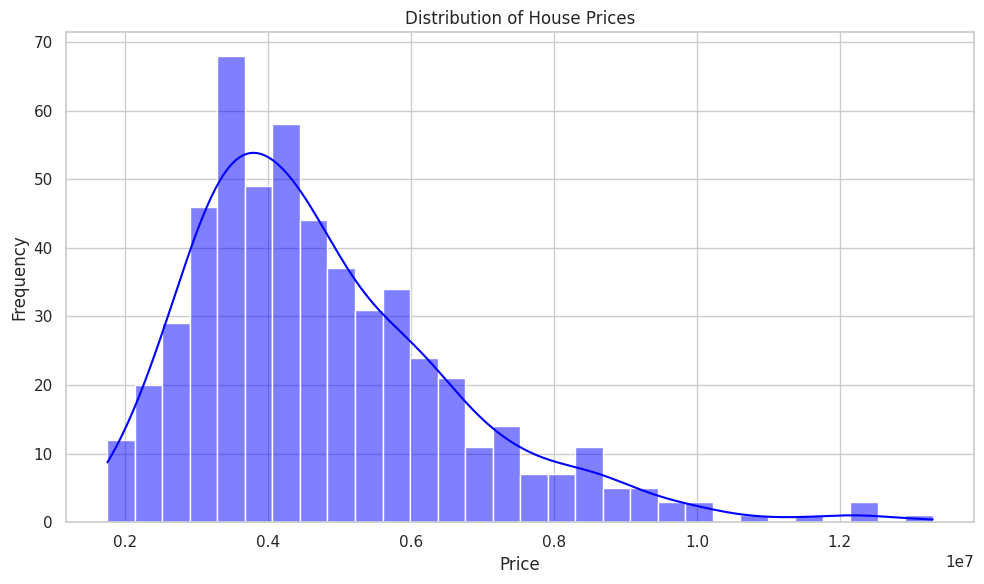

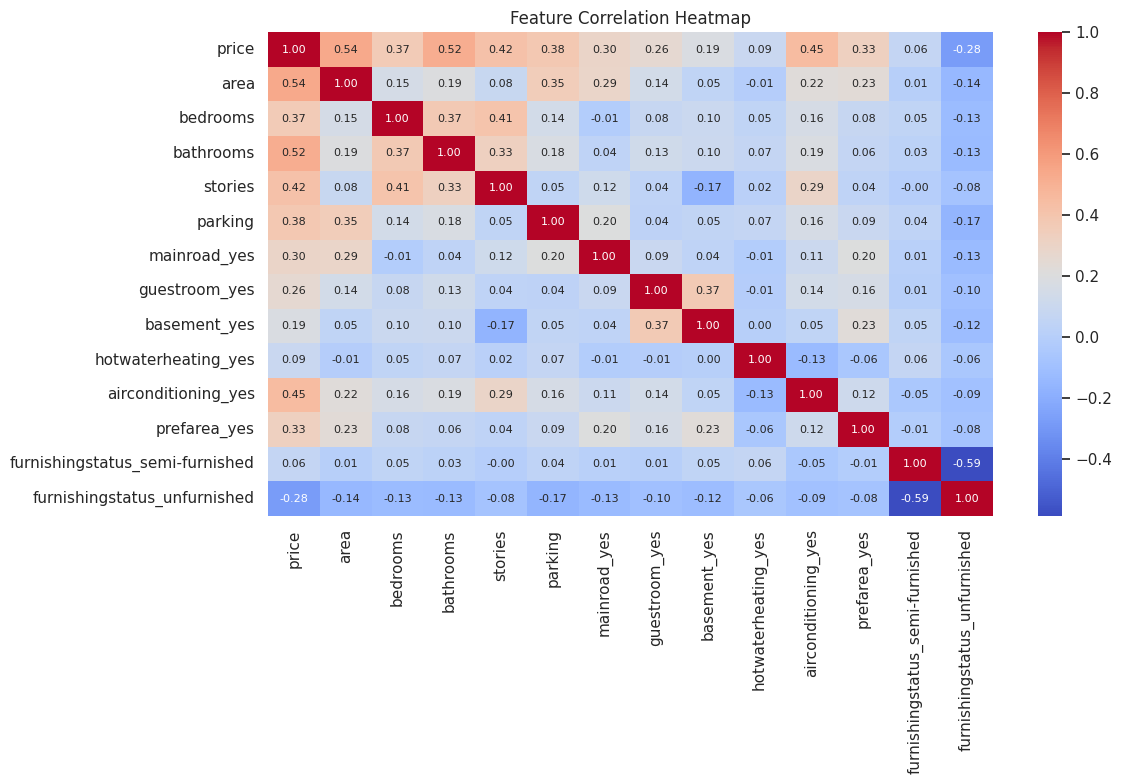

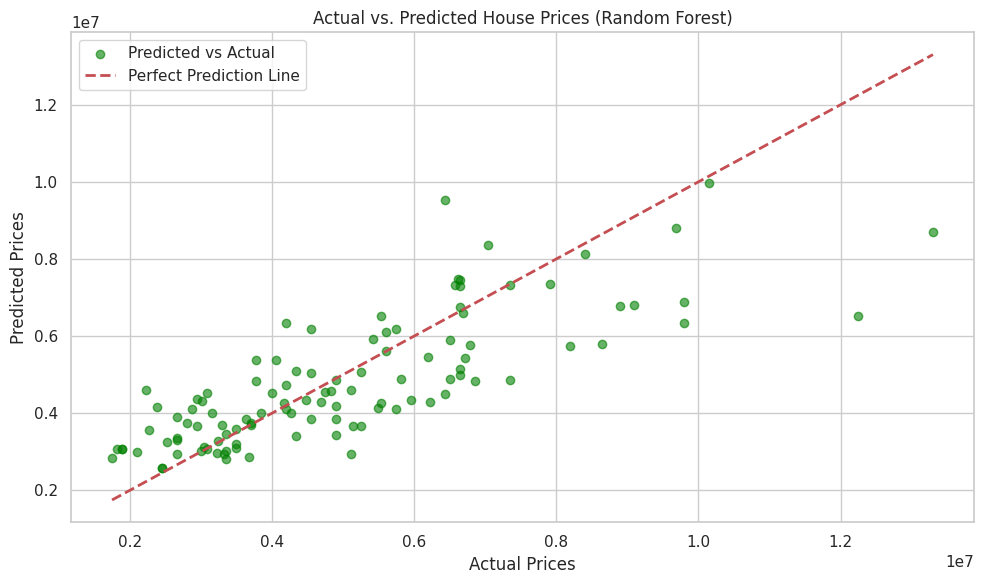


Success! All 3 charts have been generated and saved to the 'charts' folder.


In [ ]:
# ==========================================
# Task 4 — Visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a directory to save the charts for submission
if not os.path.exists('charts'):
    os.makedirs('charts')

# Set a clean visual style for the charts
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Chart 1: Histogram showing the distribution of house prices
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.histplot(df_encoded['price'], kde=True, color='blue', bins=30)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()

# Save and display
plt.savefig('charts/chart1_price_distribution.png')
plt.show()

# ---------------------------------------------------------
# Chart 2: Correlation heatmap
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
# Calculate correlations between all features and price
correlation_matrix = df_encoded.corr()

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()

# Save and display
plt.savefig('charts/chart2_correlation_heatmap.png')
plt.show()

# ---------------------------------------------------------
# Chart 3: Actual vs. Predicted Price Scatter Plot (Creative Choice)
# ---------------------------------------------------------
# For this chart, we will visualize how close our Random Forest predictions were to the actual test data.
plt.figure(figsize=(10, 6))

# Plot actual vs predicted values
plt.scatter(y_test, rf_predictions, alpha=0.6, color='green', label='Predicted vs Actual')

# Draw a diagonal dashed line representing perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')

plt.title('Actual vs. Predicted House Prices (Random Forest)')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.legend()
plt.tight_layout()

# Save and display
plt.savefig('charts/chart3_actual_vs_predicted.png')
plt.show()

print("\nSuccess! All 3 charts have been generated and saved to the 'charts' folder.")